# Imports

In [39]:

import pandas as pd
import numpy as np
import plotly.express as px
import pycountry
import missingno as msno
from sklearn.impute import SimpleImputer
import sklearn.preprocessing as sk
import os

## CSV Check

In [4]:
df = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

df.head()



,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.6+ MB


## Convert "dt" date to DateTime format
### Extract "Year" and "Month"

In [40]:
# Convert the 'dt' column to datetime format
df["dt"] = pd.to_datetime(df["dt"]) 
# Extract the year from the 'dt' column and create a new 'year' column
df["year"] = df["dt"].dt.year 
# Extract the month from the 'dt' column and create a new 'month' column
df["month"] = df["dt"].dt.month 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 6 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   dt                             577462 non-null  datetime64[ns]
 1   AverageTemperature             544811 non-null  float64       
 2   AverageTemperatureUncertainty  545550 non-null  float64       
 3   Country                        577462 non-null  object        
 4   year                           577462 non-null  int32         
 5   month                          577462 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(2), object(1)
memory usage: 22.0+ MB


# Updating Country Type
### ISO-3 standard

In [9]:
def get_iso3(country):
    try:
        return pycountry.countries.lookup(country).alpha_3
    except:
        return None

df["iso_alpha"] = df["Country"].apply(get_iso3)

In [10]:
df.info() #Check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   dt                             577462 non-null  datetime64[ns]
 1   AverageTemperature             544811 non-null  float64       
 2   AverageTemperatureUncertainty  545550 non-null  float64       
 3   Country                        577462 non-null  object        
 4   year                           577462 non-null  int32         
 5   month                          577462 non-null  int32         
 6   iso_alpha                      496152 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(2), object(2)
memory usage: 26.4+ MB


## Describe

In [11]:
df.describe()

,dt,AverageTemperature,AverageTemperatureUncertainty,year,month
count,577462,544811.000000,545550.000000,577462.000000,577462.000000
mean,1909-04-11 16:09:14.692083712,17.193354,1.019057,1908.819188,6.496098
min,1743-11-01 00:00:00,-37.658000,0.052000,1743.000000,1.000000
25%,1862-12-01 00:00:00,10.025000,0.323000,1862.000000,3.000000
50%,1914-04-01 00:00:00,20.901000,0.571000,1914.000000,6.000000
75%,1964-03-01 00:00:00,25.814000,1.206000,1964.000000,9.000000
max,2013-09-01 00:00:00,38.842000,15.003000,2013.000000,12.000000
std,NaN,10.953966,1.201930,65.916942,3.450693


<div>

• <b>Count</b>: number of valid (non-null) numerical values<br>
  → Helps identify missing data

• <b>Mean</b>: average value<br>
  → Central tendency of the distribution

• <b>Std (Standard Deviation)</b>: spread of the data<br>
&nbsp;&nbsp;&nbsp;&nbsp;• low std → stable data<br>
&nbsp;&nbsp;&nbsp;&nbsp;• high std → highly variable data<br>
  → Measures variability around the mean

• <b>Min</b>: minimum value (coldest extreme in this case)<br>
  → Possible outliers or extreme events

• <b>25% (Q1)</b>: 25th percentile<br>
  → 25% of values are below this point (cooler range)

• <b>50% (Median)</b>: middle value<br>
  → Splits the dataset in half<br>
  → More robust than mean (less sensitive to outliers)

• <b>75% (Q3)</b>: 75th percentile<br>
  → 75% of values are below this point (warmer range)

• <b>Max</b>: maximum value (hottest extreme in this case)<br>
  → Possible outliers or extreme events

</div>

In [12]:
df.columns

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country',
       'year', 'month', 'iso_alpha'],
      dtype='object')

In [13]:
df.tail() #Checking the updated dataset

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,iso_alpha
577457,2013-05-01,19.059,1.022,Zimbabwe,2013,5,ZWE
577458,2013-06-01,17.613,0.473,Zimbabwe,2013,6,ZWE
577459,2013-07-01,17.000,0.453,Zimbabwe,2013,7,ZWE
577460,2013-08-01,19.759,0.717,Zimbabwe,2013,8,ZWE
577461,2013-09-01,NaN,NaN,Zimbabwe,2013,9,ZWE


In [14]:
df.duplicated().sum()

0

## Looking for impossible data
#### Also can be checked with describe

In [15]:
df[df["AverageTemperature"] > 60]
df[df["AverageTemperature"] < -90]

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,iso_alpha


# Simple plots

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

## Global increase of Temperature

In [17]:
yearly = df.groupby("year")["AverageTemperature"].mean()


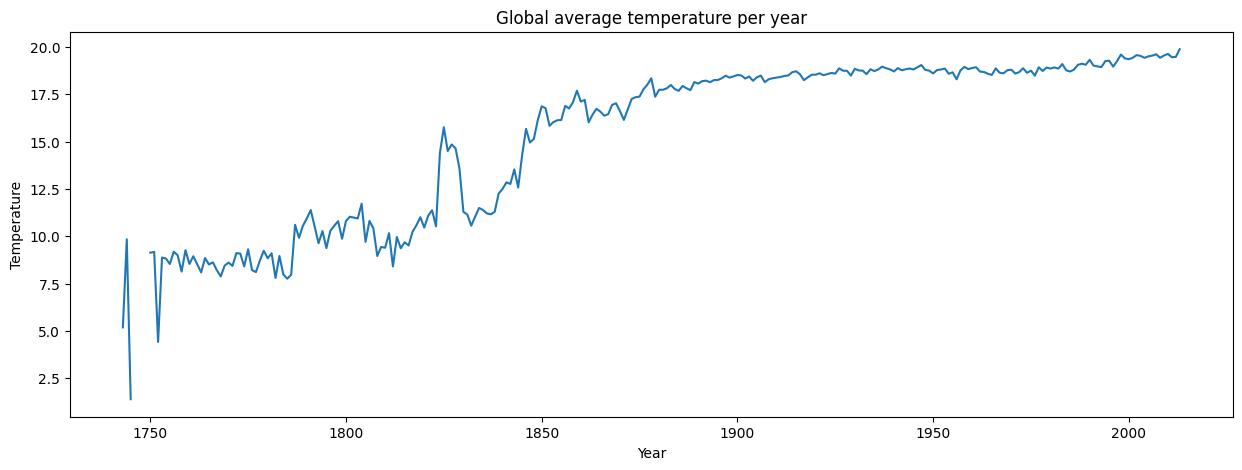

In [18]:
plt.figure(figsize=(15,5))
plt.plot(yearly.index, yearly.values)
plt.title("Global average temperature per year")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

### Strange Peaks: ~1825~
### Impossible Values: None
### Missing Years: ~1750~

# Missing Value Treatment

In [19]:
# Function for loading data
def load_data():
    data = pd.read_csv("GlobalLandTemperaturesByCountry.csv")
    return data

# Now we can call it anytime we need to load original data
data = load_data()

In [20]:
# Visualize data

# display(data)
data.head(n=10)

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
5,1744-04-01,1.530,4.680,Åland
6,1744-05-01,6.702,1.789,Åland
7,1744-06-01,11.609,1.577,Åland
8,1744-07-01,15.342,1.410,Åland
9,1744-08-01,NaN,NaN,Åland


In [21]:
# data.notna() 
data.isnull()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,False,False,False,False
1,False,True,True,False
2,False,True,True,False
3,False,True,True,False
4,False,True,True,False
...,...,...,...,...
577457,False,False,False,False
577458,False,False,False,False
577459,False,False,False,False
577460,False,False,False,False


In [22]:
# Check how many lost values we have in each column
data.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

### % Of lost Values

In [23]:
print(data.shape)
print(f"Total entries in the dataset: {data.shape[0]}")
print(len(data))


(577462, 4)
Total entries in the dataset: 577462
577462


In [24]:
data.isnull().sum()/len(data.index)*100

dt                               0.000000
AverageTemperature               5.654225
AverageTemperatureUncertainty    5.526251
Country                          0.000000
dtype: float64

## Let's check Lost Values per decade

In [29]:
# Let's take df so we have "Years" already

df["decade"] = (df["dt"].dt.year // 10) * 10
# data.isnull().sum()/len(df["decade"].index)*100
df_lostdecade = df.isnull().groupby(df["decade"]).sum().sort_index()
df_lostdecade.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,iso_alpha,decade
decade,,,,,,,,
1740,0,3050,3050,0,0,0,518,0
1750,0,560,560,0,0,0,840,0
1760,0,124,124,0,0,0,856,0
1770,0,289,289,0,0,0,995,0
1780,0,675,675,0,0,0,1116,0


## Let's make a plot so it's easier to see

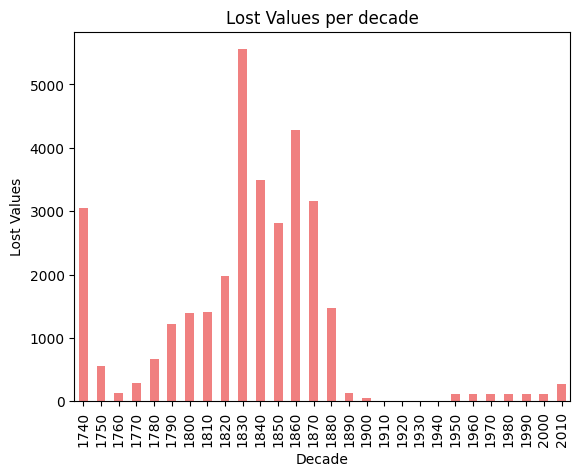

In [31]:
df_lostdecade["AverageTemperature"].plot(kind="bar", color="lightcoral")
plt.title("Lost Values per decade")
plt.xlabel("Decade")
plt.ylabel("Lost Values")
plt.show()

## And now with a Matrix to see graphically the distribution of lost values

<Axes: >

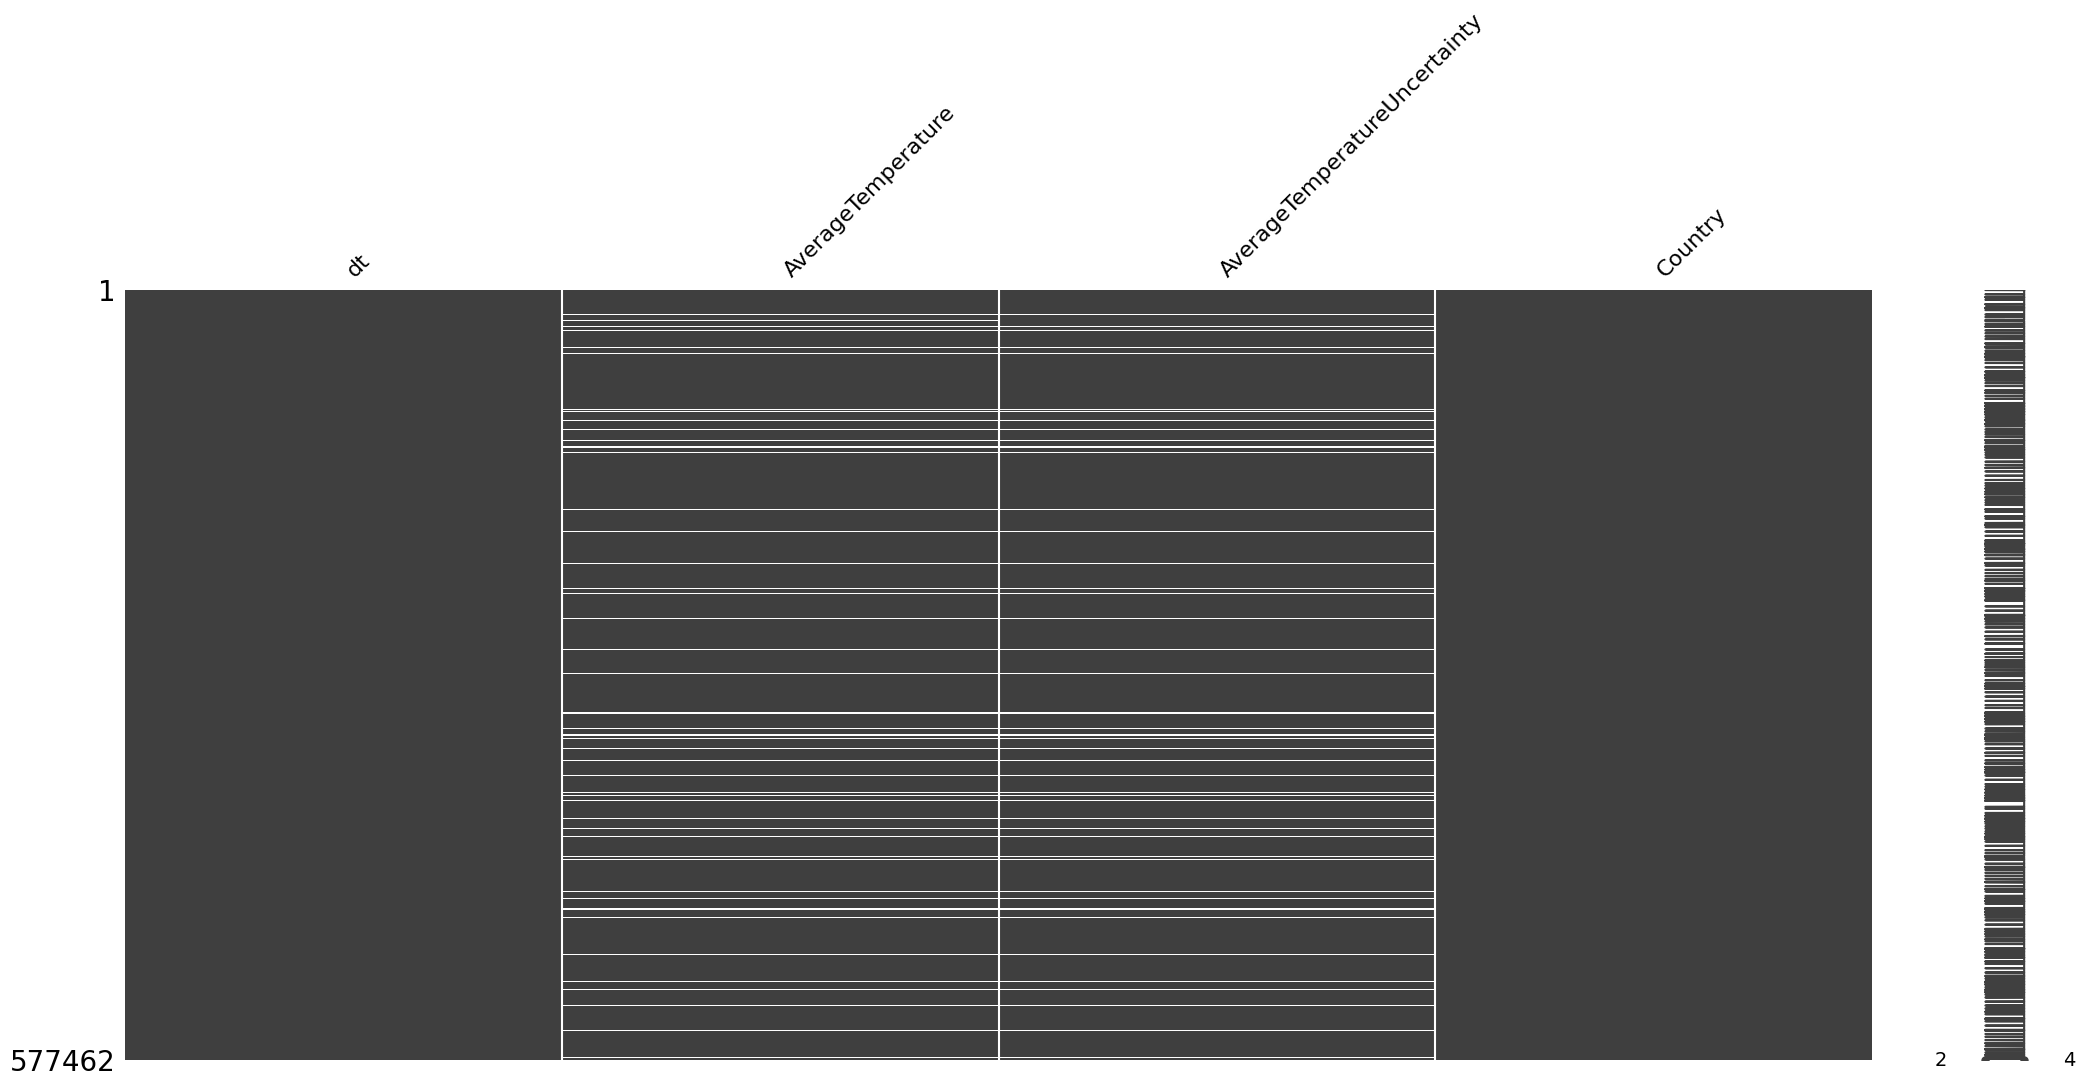

In [36]:
msno.matrix(data)

<Axes: >

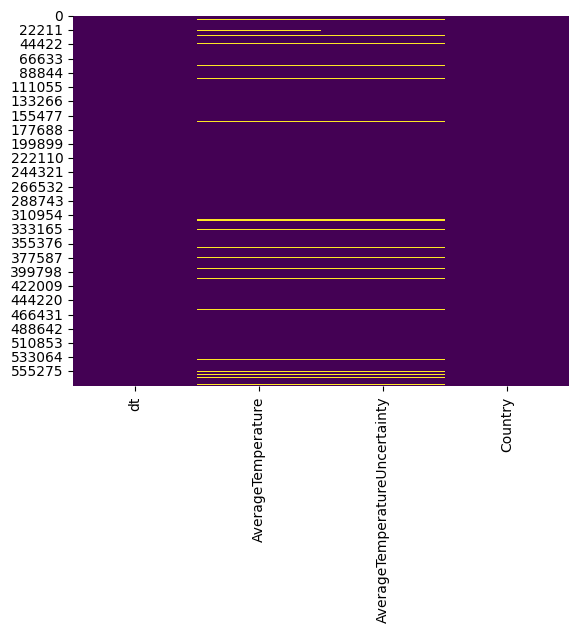

In [37]:
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")

# Let's try different ways of filling (imputing) the missing values

### SimpleImputer
#### Why can fill missing values with different "strategies":
##### mean, median, most_frequent, constant

In [51]:
# Select the data type we want to fill with out "strategy"
dataNum = data.select_dtypes(include=["float64", "bool"])

# Input our "strategy
imp = SimpleImputer(missing_values=np.nan, strategy="mean")

# And input the data (returns as an Array)
dataNum_imputed = imp.fit_transform(dataNum)

# Put it back as a DataFrame
dataNum_imputed_df = pd.DataFrame(dataNum_imputed, columns=dataNum.columns)

# Concatenate date and input data
complete_data = pd.concat([df["dt"], dataNum_imputed_df], axis=1)


In [52]:
complete_data

,dt,AverageTemperature,AverageTemperatureUncertainty
0,1743-11-01,4.384000,2.294000
1,1743-12-01,17.193354,1.019057
2,1744-01-01,17.193354,1.019057
3,1744-02-01,17.193354,1.019057
4,1744-03-01,17.193354,1.019057
...,...,...,...
577457,2013-05-01,19.059000,1.022000
577458,2013-06-01,17.613000,0.473000
577459,2013-07-01,17.000000,0.453000
577460,2013-08-01,19.759000,0.717000


## Mode Input
## Multiple Input

In [59]:
data.dtypes

dt                                object
AverageTemperature               float64
AverageTemperatureUncertainty    float64
Country                           object
dtype: object

## SNS LINEPLOT

<Axes: xlabel='year', ylabel='AverageTemperature'>

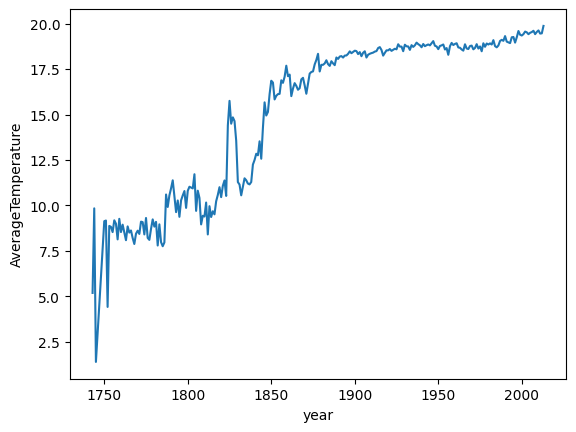

In [ ]:
sns.lineplot(data=df,  x="year", y="AverageTemperature", errorbar=None)

## Distribution

<Axes: xlabel='AverageTemperature', ylabel='Count'>

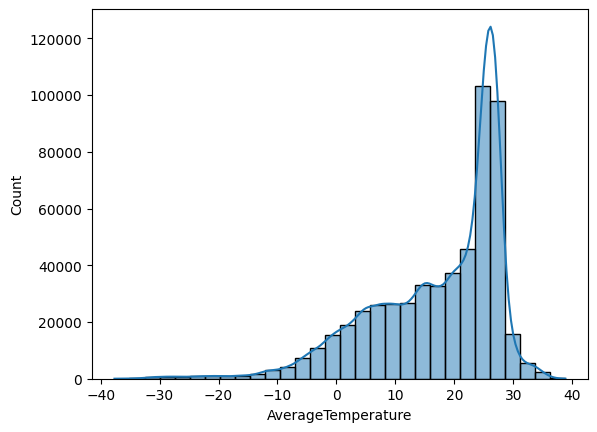

In [ ]:
sns.histplot(df["AverageTemperature"], bins=30, kde=True)

### Approximately unimodal, roughly bell-shaped. Some asymmetry with a leftward skew. Seems reasonable for a global climate series.

<h2 style="margin: 8px 0 4px 0;">MA: Moving Average</h3>
<div style="line-height: 1.75;">Suavización de ruido:<br>
&bull; En cada punto se calcula el promedio de los ultimos N puntos (MA_N)<br>
&bull; En este caso MA_10 al tratarse de una serie Mensual con bastantes cambios estacionales<br>
&bull; Recomendado MA_3 o MA_5 para series horarias/diarias. Pero diferencia case by case<br>
</div>

In [ ]:
# Moving average of 10 months  
df["MA_10"] = df["AverageTemperature"].rolling(10).mean()

# dt to datatime already done

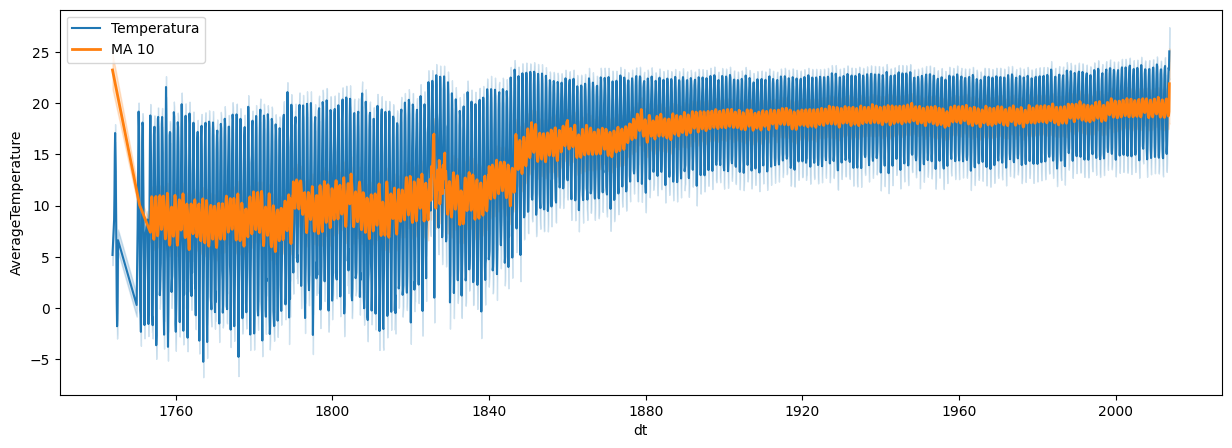

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="AverageTemperature", label="Temperatura")
sns.lineplot(data=df, x="dt", y="MA_10", label="MA 10", linewidth=2)

plt.show()

<h3 style="margin: 8px 0 4px 0;">Línea móvil</h3>
<div style="line-height: 1.25;">
<span style="color:blue;">Azul:</span> Variabilidad climática real (Estacional + extremos)<br>
<span style="color:darkorange;">Naranja:</span> Tendencia subyacente del clima
</div>

### Estudio de cambio climático con MA 50

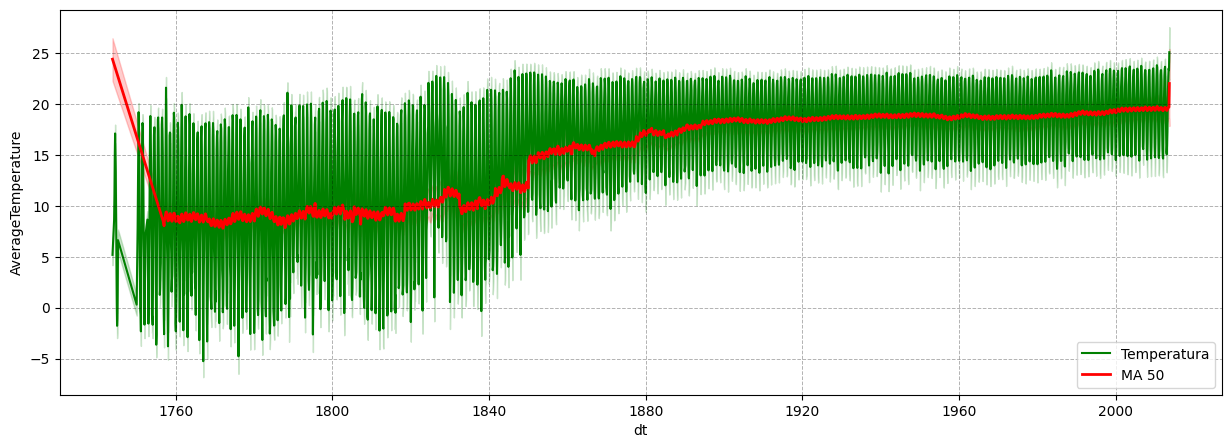

In [ ]:
df["MA_50"] = df["AverageTemperature"].rolling(50).mean()
# Ligero cambio de color para diferenciar mejor las líneas
plt.figure(figsize=(15,5))
ax = plt.gca() # Obtener el eje actual para ajustar el grid encima de las líneas

sns.lineplot(
    data=df,
    x="dt",
    y="AverageTemperature",
    label="Temperatura",
    linewidth=1.5,
    color="green")
sns.lineplot(
    data=df,
    x="dt",
    y="MA_50",
    label="MA 50",
    linewidth=2,
    color="red")

# Ajustar el grid para que esté encima de las líneas
ax.set_axisbelow(False)
ax.grid(
    True,
    color = "black",
    linewidth=0.7,
    alpha=0.3,
    linestyle="--"
)

plt.show()

## Correlación Temporal
#### Cambios de temperatura mes a mes

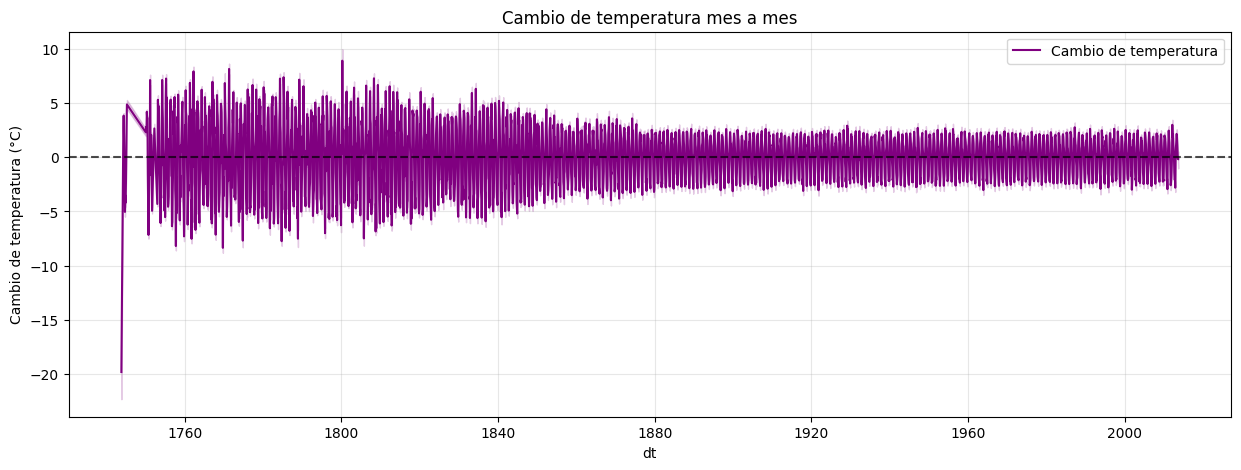

In [ ]:
df["temp_change"] = df["AverageTemperature"].diff() 
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="temp_change", label="Cambio de temperatura", color="purple")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.title("Cambio de temperatura mes a mes")    
plt.ylabel("Cambio de temperatura (°C)")

plt.show()

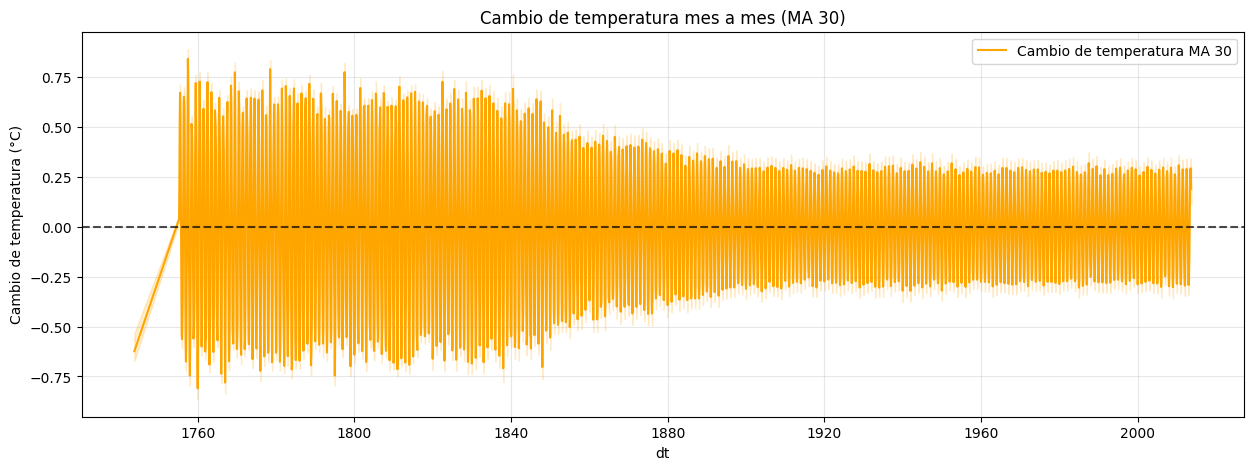

In [ ]:
# Suavizamos el cambio de temperatura con una media móvil de 30 meses
df["temp_change_MA30"] = df["temp_change"].rolling(30).mean()
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="temp_change_MA30", label="Cambio de temperatura MA 30", color="orange")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.title("Cambio de temperatura mes a mes (MA 30)")    
plt.ylabel("Cambio de temperatura (°C)")

plt.show()

#### La variabilidad del cambio de temperatura mensual es menor en el periodo moderno, lo que puede reflejar tanto una mayor estabilidad en las series recientes como, muy probablemente, una mejora en la calidad y consistencia de las mediciones a partir de finales del siglo XIX

## ¿Es cada década más caliente a la anterior?

In [ ]:
# df["decade"] = (df["dt"].dt.year // 10) * 10 #Lost Values
decadal_mean = df.groupby("decade")["AverageTemperature"].mean().sort_index()
decadal_change = decadal_mean.diff()

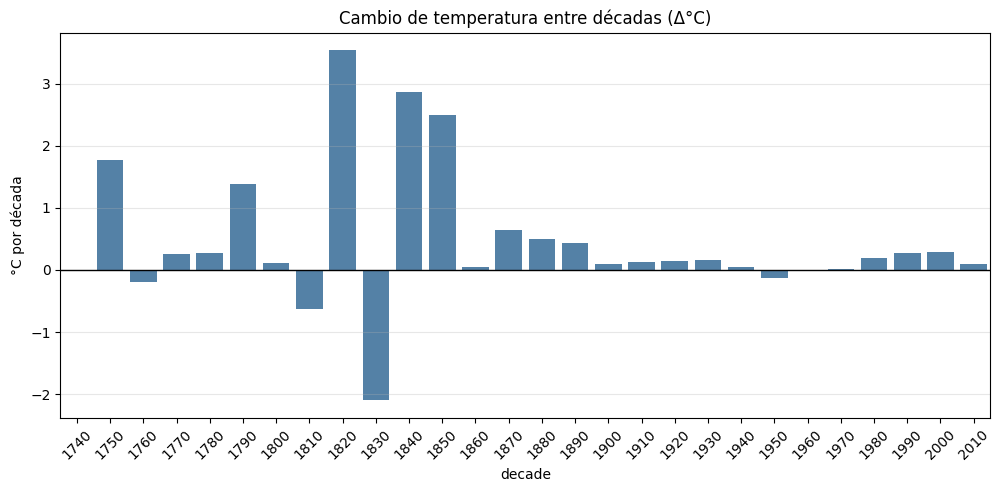

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(x=decadal_change.index, y=decadal_change.values, color="steelblue")

plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45)
plt.title("Cambio de temperatura entre décadas (Δ°C)")
plt.ylabel("°C por década")
plt.grid(True, axis="y", alpha=0.3)

#### A partir de 1880 vemos como hay un incremento pequeño pero estable década a década de la temperatura global
#### Aunque anteriormente los cambios son más bruscos, podemos achacarlo a que los métodos de medida no eran tan exactos como en épocas más recientes

In [ ]:
df_1880 = df[df["year"] >= 1880]
dec_from_1880 = df_1880.groupby("decade")["AverageTemperature"].mean().sort_index()
dec_from_1880_change = dec_from_1880.diff()

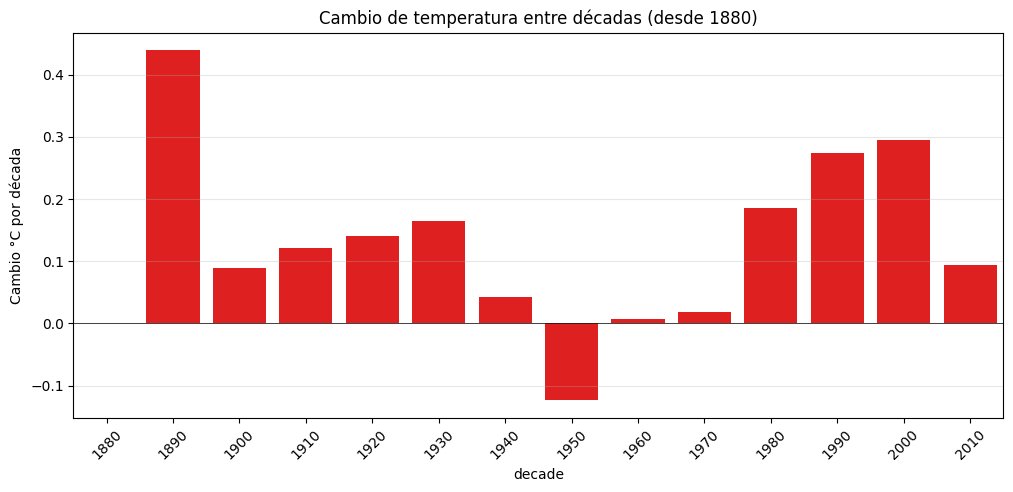

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(x=dec_from_1880_change.index, y=dec_from_1880_change.values, color="red")

plt.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=45)
plt.title("Cambio de temperatura entre décadas (desde 1880)")
plt.ylabel("Cambio °C por década")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [ ]:
nan_by_decade = df_1880.groupby("decade")["AverageTemperature"].apply(lambda x: x.isna().sum())
print(nan_by_decade)

decade
1880    1474
1890     134
1900      51
1910       0
1920       5
1930       1
1940       6
1950     121
1960     120
1970     120
1980     120
1990     120
2000     120
2010     266
Name: AverageTemperature, dtype: int64


In [ ]:
count_by_decade = df_1880.groupby("decade")["AverageTemperature"].count()
print(count_by_decade)

decade
1880    26810
1890    28368
1900    28677
1910    28800
1920    28795
1930    28799
1940    28840
1950    29038
1960    29040
1970    29040
1980    29040
1990    29040
2000    29040
2010    10669
Name: AverageTemperature, dtype: int64


In [ ]:
missing_pct = nan_by_decade / (nan_by_decade + count_by_decade) * 100
print(missing_pct)

decade
1880    5.211427
1890    0.470142
1900    0.177527
1910    0.000000
1920    0.017361
1930    0.003472
1940    0.020800
1950    0.414966
1960    0.411523
1970    0.411523
1980    0.411523
1990    0.411523
2000    0.411523
2010    2.432556
Name: AverageTemperature, dtype: float64


In [ ]:
from scipy.stats import linregress

df_1880 = df[df["dt"].dt.year >= 1880].copy()

df_1880["decade"] = (df_1880["dt"].dt.year // 10) * 10
dec = df_1880.groupby("decade")["AverageTemperature"].mean()

x = dec.index.values
y = dec.values

slope, intercept, r, p, std = linregress(x, y)

In [ ]:
slope_per_decade = slope * 10
print(slope_per_decade)

0.10300271721357794


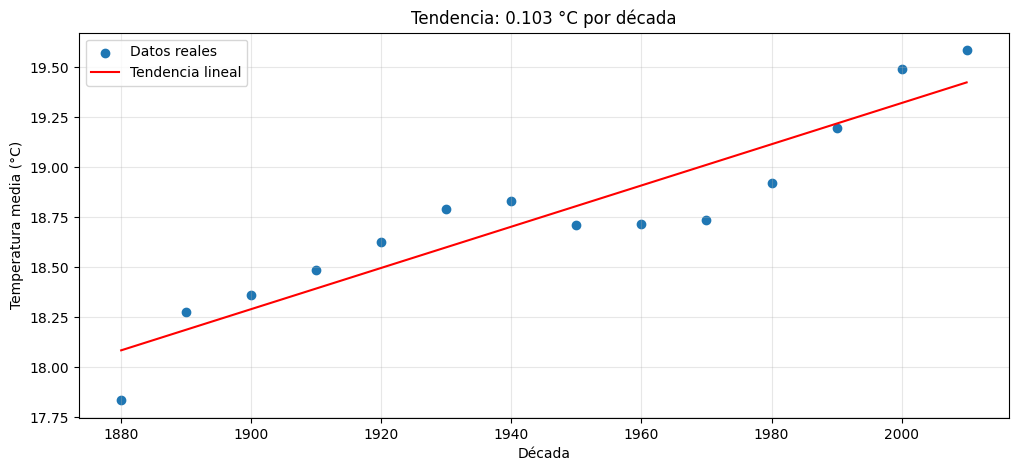

In [ ]:
plt.figure(figsize=(12,5))

plt.scatter(x, y, label="Datos reales")
plt.plot(x, intercept + slope*x, color="red", label="Tendencia lineal")

plt.title(f"Tendencia: {slope_per_decade:.3f} °C por década")
plt.xlabel("Década")
plt.ylabel("Temperatura media (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# MAPAMUNDI

In [ ]:

# promedio por país
country_temp = df.groupby("Country")["AverageTemperature"].mean().reset_index()

# añadir ISO al dataset agregado
country_temp["iso_alpha"] = country_temp["Country"].apply(get_iso3)

fig = px.choropleth(
    country_temp,
    locations="iso_alpha",
    color="AverageTemperature",
    color_continuous_scale="RdYlBu_r",
    title="Global Average Temperature by Country"
)

fig.show()



In [ ]:

df["dt"] = pd.to_datetime(df["dt"])

# 🔥 anomalía global (baseline)
df["anomaly"] = df["AverageTemperature"] - df["AverageTemperature"].mean()

# 📊 agregar por país
country_anomaly = df.groupby("Country")["anomaly"].mean().reset_index()

# 🌍 convertir a ISO-3
country_anomaly["iso_alpha"] = country_anomaly["Country"].apply(get_iso3)

# 🗺️ mapa correcto
fig = px.choropleth(
    country_anomaly,
    locations="iso_alpha",
    color="anomaly",
    color_continuous_scale="RdBu_r",
    title="Global Temperature Anomaly by Country"
)

fig.show()

In [ ]:
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year.astype(int)

country_year = df.groupby(["Country", "year"])["AverageTemperature"].mean().reset_index()
country_year["iso_alpha"] = country_year["Country"].apply(get_iso3)

country_year = country_year.sort_values("year")

fig = px.choropleth(
    country_year,
    locations="iso_alpha",
    color="AverageTemperature",
    animation_frame="year",
    color_continuous_scale="RdYlBu_r",
    title="Global Temperature Evolution by Country"
)

fig.show()